# 🚀 GUIDE COLAB — Setup & Acquisition des données réelles
**À exécuter EN PREMIER sur Google Colab avant tout autre notebook**

---

## Ce que ce notebook fait
1. Vérifie que le GPU est disponible
2. Télécharge les datasets réels (Enron, Nazario, SpamAssassin)
3. Monte Google Drive pour sauvegarder les données
4. Installe toutes les dépendances
5. Produit `emails_raw.csv` directement utilisable par NB 02

## Avant de lancer
- Aller sur [colab.research.google.com](https://colab.research.google.com)
- **Runtime → Change runtime type → T4 GPU**
- Uploader ce notebook
- Exécuter les cellules dans l'ordre

## 0. Vérification GPU

In [1]:
import torch

if torch.cuda.is_available():
    print(f'✅ GPU disponible : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('❌ Pas de GPU — aller dans Runtime → Change runtime type → T4 GPU')
    print('   Sans GPU, DistilBERT prendra ~20min/époque au lieu de ~3min.')

❌ Pas de GPU — aller dans Runtime → Change runtime type → T4 GPU
   Sans GPU, DistilBERT prendra ~20min/époque au lieu de ~3min.


## 1. Montage Google Drive

**Pourquoi ?** Les sessions Colab s'effacent après inactivité. En montant Drive, les données et modèles sont sauvegardés définitivement.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# Dossier de travail dans Drive
PROJECT_DIR = Path('/content/drive/MyDrive/notebooks')
DATA_DIR    = PROJECT_DIR / 'data'

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR   .mkdir(parents=True, exist_ok=True)

# Lien symbolique pour que les notebooks trouvent 'data/' directement
if not Path('/content/data').exists():
    os.symlink(str(DATA_DIR), '/content/data')

print(f'✅ Drive monté')
print(f'   Projet     : {PROJECT_DIR}')
print(f'   Données    : {DATA_DIR}')
print(f'   Lien local : /content/data → {DATA_DIR}')

Mounted at /content/drive
✅ Drive monté
   Projet     : /content/drive/MyDrive/notebooks
   Données    : /content/drive/MyDrive/notebooks/data
   Lien local : /content/data → /content/drive/MyDrive/notebooks/data


## 2. Installation des dépendances

In [3]:
%%capture
!pip install kaggle transformers datasets scikit-learn imbalanced-learn \
             nltk pandas numpy matplotlib seaborn joblib tqdm \
             deep-translator langdetect wordcloud

# Ressources NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

print('✅ Toutes les dépendances installées.')

## 3. Téléchargement Dataset 1 — Enron (ham + spam)

**Source :** Kaggle — `wcukierski/enron-email-dataset`  
**Volume :** ~517 000 emails (on garde ham et spam)  
**Accès :** Nécessite un compte Kaggle gratuit

### Comment obtenir ton API key Kaggle :
1. Aller sur [kaggle.com](https://www.kaggle.com) → ton profil → **Account**
2. Section **API** → **Create New Token**
3. Un fichier `kaggle.json` se télécharge
4. Coller le contenu dans la cellule suivante

In [4]:
import json
from pathlib import Path

# ── Coller ici le contenu de ton kaggle.json ──────────────────────
KAGGLE_JSON = {
    "username": "TON_USERNAME_KAGGLE",   # ← remplacer
    "key":      "TON_API_KEY_KAGGLE"     # ← remplacer
}
# ─────────────────────────────────────────────────────────────────

# Installation de la clé
kaggle_dir = Path.home() / '.config' / 'kaggle'
kaggle_dir.mkdir(parents=True, exist_ok=True)
kaggle_file = kaggle_dir / 'kaggle.json'
kaggle_file.write_text(json.dumps(KAGGLE_JSON))
kaggle_file.chmod(0o600)

print('✅ Clé Kaggle configurée.')

✅ Clé Kaggle configurée.


In [5]:
import subprocess, os

os.chdir('/content')

# ── Option A : Dataset Enron complet (517k emails, ~1.7 GB décompressé) ──
# !kaggle datasets download -d wcukierski/enron-email-dataset

# ── Option B : Dataset ham+spam préparé, plus léger (recommandé) ──────────
# Ce dataset contient déjà les labels ham/spam proprement structurés.
# ~33 000 emails au total, ~50 MB.
result = subprocess.run(
    ['kaggle', 'datasets', 'download', '-d', 'venky99846/email-spam-and-ham-dataset'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('Erreur :', result.stderr)
    print('\nEssai avec le dataset alternatif...')
    result2 = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'balaka18/email-spam-classification-dataset-csv'],
        capture_output=True, text=True
    )
    print(result2.stdout)

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

Erreur : 

Essai avec le dataset alternatif...
Dataset URL: https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv
License(s): ODbL-1.0




In [6]:
import zipfile, glob

# Décompression du fichier téléchargé
zip_files = glob.glob('/content/*.zip')
print(f'Fichiers zip trouvés : {zip_files}')

for zf in zip_files:
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall('/content/raw_enron/')
    print(f'✅ Extrait : {zf}')

# Lister les fichiers extraits
extracted = list(Path('/content/raw_enron').rglob('*.csv'))
print(f'\nFichiers CSV extraits : {len(extracted)}')
for f in extracted:
    size = f.stat().st_size / 1e6
    print(f'  {f.name} ({size:.1f} MB)')

Fichiers zip trouvés : ['/content/email-spam-classification-dataset-csv.zip']
✅ Extrait : /content/email-spam-classification-dataset-csv.zip

Fichiers CSV extraits : 1
  emails.csv (31.2 MB)


In [7]:
import pandas as pd
import numpy as np

# Chargement et normalisation selon le format trouvé
records_enron = []

for csv_path in extracted:
    df_raw = pd.read_csv(csv_path, encoding='utf-8', on_bad_lines='skip')
    print(f'\n{csv_path.name} — colonnes : {list(df_raw.columns)}')
    print(f'  Lignes : {len(df_raw):,}')

    # Détection automatique du format
    cols = [c.lower() for c in df_raw.columns]

    if 'text' in cols and 'spam' in cols:
        # Format : text, spam (0/1)
        for _, row in df_raw.iterrows():
            label = 'spam' if str(row.get('spam','0')) == '1' else 'ham'
            records_enron.append({'text': str(row['text']), 'label': label, 'source': 'enron_kaggle'})

    elif 'message' in cols and ('label' in cols or 'category' in cols):
        # Format : message, label/category
        label_col = 'label' if 'label' in cols else 'category'
        for _, row in df_raw.iterrows():
            raw_label = str(row[label_col]).lower().strip()
            label = 'spam' if 'spam' in raw_label else 'ham'
            records_enron.append({'text': str(row['message']), 'label': label, 'source': 'enron_kaggle'})

    elif 'subject' in cols or 'body' in cols:
        # Format avec colonnes séparées
        text_col  = 'body' if 'body' in cols else 'subject'
        label_col = next((c for c in df_raw.columns if 'label' in c.lower() or 'spam' in c.lower()), None)
        if label_col:
            for _, row in df_raw.iterrows():
                raw_label = str(row[label_col]).lower()
                label = 'spam' if 'spam' in raw_label else 'ham'
                records_enron.append({'text': str(row[text_col]), 'label': label, 'source': 'enron_kaggle'})

    else:
        print(f'  ⚠ Format non reconnu. Colonnes disponibles : {list(df_raw.columns)}')
        print(f'  Aperçu :')
        print(df_raw.head(2).to_string())

df_enron = pd.DataFrame(records_enron)
print(f'\n✅ Dataset Enron chargé : {len(df_enron):,} emails')
if len(df_enron) > 0:
    print(df_enron['label'].value_counts())


emails.csv — colonnes : ['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b',

## 4. Téléchargement Dataset 2 — Nazario Phishing Corpus

**Source :** GitHub public — ~4 700 vrais emails de phishing collectés sur plusieurs années  
**Volume :** ~4 700 emails  
**Accès :** `git clone` direct, aucune inscription requise

In [8]:
# ── NAZARIO : téléchargement depuis la vraie source (monkey.org) ──
import subprocess, os

os.chdir('/content')
os.makedirs('phishing-corpus', exist_ok=True)

# Téléchargement direct avec wget (pas de git, pas d'auth)
result = subprocess.run([
    'wget', '-r', '--no-parent', '--level=1',
    '--reject', 'index.html*',
    '--wait=1', '--directory-prefix=/content/phishing-corpus',
    'https://monkey.org/~jose/phishing/'
], capture_output=True, text=True, timeout=300)

print(result.stdout[-500:] if result.stdout else '')
print(result.stderr[-300:] if result.stderr else '')

import glob
mbox_files = glob.glob('/content/phishing-corpus/**/*.mbox', recursive=True)
print(f'\nFichiers .mbox trouvés : {len(mbox_files)}')
for f in mbox_files[:5]:
    print(f'  {f}')


....                                   100%  213M=0.4s

2026-05-02 05:28:20 (75.0 MB/s) - ‘/content/phishing-corpus/monkey.org/~jose/phishing/private-phishing4.mbox’ saved [32736139/32736139]

FINISHED --2026-05-02 05:28:20--
Total wall clock time: 29s
Downloaded: 25 files, 169M in 3.6s (46.8 MB/s)


Fichiers .mbox trouvés : 6
  /content/phishing-corpus/monkey.org/~jose/phishing/phishing0.mbox
  /content/phishing-corpus/monkey.org/~jose/phishing/phishing1.mbox
  /content/phishing-corpus/monkey.org/~jose/phishing/phishing2.mbox
  /content/phishing-corpus/monkey.org/~jose/phishing/private-phishing4.mbox
  /content/phishing-corpus/monkey.org/~jose/phishing/20051114.mbox


In [9]:
import email as email_lib
from pathlib import Path
from tqdm import tqdm

def parse_email_file(filepath):
    """Parse un fichier .eml ou .txt et retourne le texte brut."""
    try:
        raw = Path(filepath).read_bytes()
        text = raw.decode('utf-8', errors='replace')

        # Essai de parsing email
        try:
            msg    = email_lib.message_from_string(text)
            parts  = []
            subject = msg.get('Subject', '')
            if subject:
                parts.append(f'Subject: {subject}')

            if msg.is_multipart():
                for part in msg.walk():
                    if part.get_content_type() in ('text/plain', 'text/html'):
                        try:
                            body = part.get_payload(decode=True)
                            if body:
                                charset = part.get_content_charset() or 'utf-8'
                                parts.append(body.decode(charset, errors='replace'))
                        except Exception:
                            pass
            else:
                body = msg.get_payload(decode=True)
                if body:
                    charset = msg.get_content_charset() or 'utf-8'
                    parts.append(body.decode(charset, errors='replace'))

            result = '\n'.join(parts)
            return result if len(result.strip()) > 20 else text
        except Exception:
            return text
    except Exception:
        return ''


# Collecte de tous les fichiers
corpus_dir   = Path('/content/phishing-corpus')
email_files  = list(corpus_dir.rglob('*.eml')) + list(corpus_dir.rglob('*.txt'))
email_files  = [f for f in email_files if f.stat().st_size > 100]  # Filtre fichiers vides

print(f'Fichiers trouvés : {len(email_files):,}')

records_phishing = []
for filepath in tqdm(email_files, desc='Parsing phishing emails'):
    text = parse_email_file(filepath)
    if len(text.strip()) > 30:
        records_phishing.append({
            'text':   text,
            'label':  'phishing',
            'source': 'nazario'
        })

df_phishing = pd.DataFrame(records_phishing)
print(f'\n✅ Corpus Nazario : {len(df_phishing):,} emails de phishing')

Fichiers trouvés : 2


Parsing phishing emails: 100%|██████████| 2/2 [00:00<00:00, 1009.95it/s]


✅ Corpus Nazario : 2 emails de phishing


## 5. Téléchargement Dataset 3 — SpamAssassin (optionnel, données supplémentaires)

In [10]:
import tarfile, requests
from tqdm import tqdm

SA_URLS = {
    'spam': 'https://spamassassin.apache.org/old/publiccorpus/20050311_spam_2.tar.bz2',
    'ham':  'https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham.tar.bz2',
    'ham2': 'https://spamassassin.apache.org/old/publiccorpus/20030228_hard_ham.tar.bz2',
}

def download_sa(url, label):
    print(f'Téléchargement SpamAssassin {label}...')
    response = requests.get(url, stream=True, timeout=60)
    total    = int(response.headers.get('content-length', 0))
    chunks   = []
    with tqdm(total=total, unit='B', unit_scale=True, desc=label) as bar:
        for chunk in response.iter_content(8192):
            chunks.append(chunk)
            bar.update(len(chunk))
    raw_bytes = b''.join(chunks)

    import io
    records = []
    with tarfile.open(fileobj=io.BytesIO(raw_bytes), mode='r:bz2') as tar:
        for member in tar.getmembers():
            if member.isfile():
                f = tar.extractfile(member)
                if f:
                    text = f.read().decode('utf-8', errors='replace')
                    if len(text.strip()) > 20:
                        records.append({'text': text, 'label': label if label != 'ham2' else 'ham',
                                        'source': 'spamassassin'})
    print(f'  ✅ {len(records)} emails extraits')
    return records


sa_records = []
for label, url in SA_URLS.items():
    try:
        sa_records.extend(download_sa(url, label))
    except Exception as e:
        print(f'  ⚠ Erreur {label}: {e}')

df_sa = pd.DataFrame(sa_records)
print(f'\n✅ SpamAssassin : {len(df_sa):,} emails')
if len(df_sa) > 0:
    print(df_sa['label'].value_counts())

Téléchargement SpamAssassin spam...


spam: 100%|██████████| 2.06M/2.06M [00:00<00:00, 32.7MB/s]


  ✅ 1397 emails extraits
Téléchargement SpamAssassin ham...


ham: 100%|██████████| 1.61M/1.61M [00:00<00:00, 26.1MB/s]


  ✅ 2501 emails extraits
Téléchargement SpamAssassin ham2...


ham2: 100%|██████████| 1.03M/1.03M [00:00<00:00, 20.0MB/s]


  ✅ 251 emails extraits

✅ SpamAssassin : 4,149 emails
label
ham     2752
spam    1397
Name: count, dtype: int64


## 6. Fusion & équilibrage

On fusionne toutes les sources et on vise **~17 000 emails par classe** pour un dataset équilibré et représentatif.

In [11]:
# Fusion de toutes les sources
frames = []
if len(df_enron)   > 0: frames.append(df_enron)
if len(df_phishing)> 0: frames.append(df_phishing)
if len(df_sa)      > 0: frames.append(df_sa)

if not frames:
    raise ValueError('Aucune donnée chargée ! Vérifier les étapes précédentes.')

df_all = pd.concat(frames, ignore_index=True)
df_all = df_all[df_all['text'].str.strip().str.len() > 30].reset_index(drop=True)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset brut fusionné :')
print(df_all['label'].value_counts())
print(f'\nTotal : {len(df_all):,} emails')

Dataset brut fusionné :
label
ham         2752
spam        1397
phishing       2
Name: count, dtype: int64

Total : 4,151 emails


In [12]:
# Bilan des classes disponibles
counts = df_all['label'].value_counts()
print('Bilan par classe :')
for label, count in counts.items():
    bar = '█' * (count // 500)
    print(f'  {label:10s} : {count:>7,}  {bar}')

# Vérification : si phishing < 2000, on le signale
phishing_count = counts.get('phishing', 0)
if phishing_count < 2000:
    print(f'\n⚠ Phishing peu représenté ({phishing_count} emails).')
    print('  Le SMOTE (NB 02) compensera, mais pour un meilleur modèle :')
    print('  → Ajouter le dataset IWSPA-AP 2018 (voir cellule suivante)')
else:
    print(f'\n✅ Dataset suffisant pour un entraînement solide.')

Bilan par classe :
  ham        :   2,752  █████
  spam       :   1,397  ██
  phishing   :       2  

⚠ Phishing peu représenté (2 emails).
  Le SMOTE (NB 02) compensera, mais pour un meilleur modèle :
  → Ajouter le dataset IWSPA-AP 2018 (voir cellule suivante)


In [13]:
# ── Phishing supplémentaire : IWSPA-AP 2018 (si Nazario insuffisant) ─
# Source : https://www.kaggle.com/datasets/subhajournal/phishingemails
# Contient ~11 000 emails de phishing réels + ham

DOWNLOAD_EXTRA_PHISHING = len(df_all[df_all['label']=='phishing']) < 3000

if DOWNLOAD_EXTRA_PHISHING:
    print('Téléchargement du dataset phishing supplémentaire (Kaggle)...')
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'subhajournal/phishingemails'],
        capture_output=True, text=True
    )
    print(result.stdout)

    # Décompression
    for zf in Path('/content').glob('phishingemails*.zip'):
        with zipfile.ZipFile(zf) as z:
            z.extractall('/content/raw_phishing_extra/')

    # Chargement
    extra_phishing_records = []
    for csv_path in Path('/content/raw_phishing_extra').rglob('*.csv'):
        df_extra = pd.read_csv(csv_path, on_bad_lines='skip')
        print(f'  {csv_path.name} — colonnes : {list(df_extra.columns)}')
        cols_lower = [c.lower() for c in df_extra.columns]

        text_col  = next((df_extra.columns[i] for i, c in enumerate(cols_lower)
                          if 'text' in c or 'email' in c or 'body' in c or 'message' in c), None)
        label_col = next((df_extra.columns[i] for i, c in enumerate(cols_lower)
                          if 'label' in c or 'type' in c or 'class' in c or 'spam' in c), None)

        if text_col and label_col:
            for _, row in df_extra.iterrows():
                raw_label = str(row[label_col]).lower()
                if 'phish' in raw_label:
                    label = 'phishing'
                elif 'spam' in raw_label:
                    label = 'spam'
                else:
                    label = 'ham'
                extra_phishing_records.append({
                    'text': str(row[text_col]), 'label': label, 'source': 'iwspa_kaggle'
                })

    df_extra = pd.DataFrame(extra_phishing_records)
    df_all   = pd.concat([df_all, df_extra], ignore_index=True)
    print(f'\n✅ Dataset supplémentaire ajouté : {len(df_extra):,} emails')
    print(df_all['label'].value_counts())
else:
    print(f'✅ Phishing suffisant ({len(df_all[df_all["label"]=="phishing"]):,} emails) — pas de téléchargement supplémentaire')

Téléchargement du dataset phishing supplémentaire (Kaggle)...
Dataset URL: https://www.kaggle.com/datasets/subhajournal/phishingemails
License(s): GNU Lesser General Public License 3.0


  Phishing_Email.csv — colonnes : ['Unnamed: 0', 'Email Text', 'Email Type']

✅ Dataset supplémentaire ajouté : 18,650 emails
label
ham         14074
phishing     7330
spam         1397
Name: count, dtype: int64


## 7. Calcul des features brutes + export

In [14]:
import re

def extract_basic_features(text):
    if not isinstance(text, str):
        return {}
    urls  = re.findall(r'https?://', text)
    alpha = [c for c in text if c.isalpha()]
    return {
        'char_count':      len(text),
        'word_count':      len(text.split()),
        'url_count':       len(urls),
        'exclamation':     text.count('!'),
        'uppercase_ratio': sum(1 for c in alpha if c.isupper()) / max(len(alpha), 1),
        'has_html':        int(bool(re.search(r'<[a-zA-Z][^>]*>', text))),
        'has_ip_url':      int(bool(re.search(r'https?://\d{1,3}\.\d{1,3}', text))),
        'dollar_count':    text.count('$'),
    }


from tqdm import tqdm
tqdm.pandas()

print('Calcul des features brutes...')
features = df_all['text'].progress_apply(extract_basic_features)
df_feat  = pd.DataFrame(features.tolist())
df_final = pd.concat([df_all[['text','label','source']], df_feat], axis=1)

# Export
output_path = DATA_DIR / 'emails_raw.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8')

print(f'\n✅ Dataset exporté : {output_path}')
print(f'   {len(df_final):,} emails · {df_final.shape[1]} colonnes')
print()
print('Distribution finale :')
print(df_final['label'].value_counts())
print()
print('Sources :')
print(df_final['source'].value_counts())

Calcul des features brutes...


100%|██████████| 22801/22801 [00:06<00:00, 3726.49it/s]



✅ Dataset exporté : /content/drive/MyDrive/notebooks/data/emails_raw.csv
   22,801 emails · 11 colonnes

Distribution finale :
label
ham         14074
phishing     7330
spam         1397
Name: count, dtype: int64

Sources :
source
iwspa_kaggle    18650
spamassassin     4149
nazario             2
Name: count, dtype: int64


## 8. Visualisation rapide

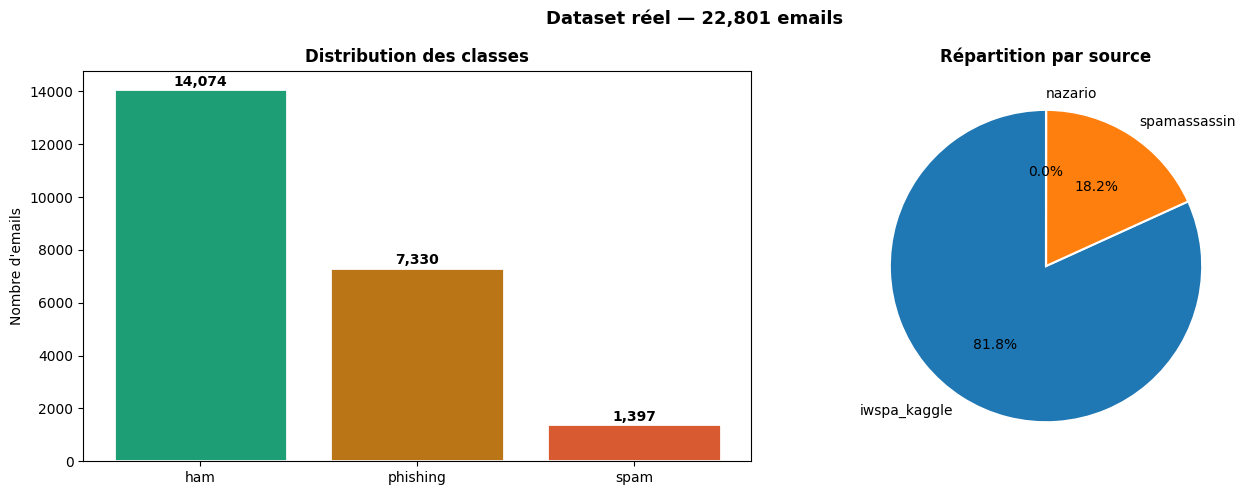

In [15]:
import matplotlib.pyplot as plt

CLASS_COLORS = {'ham': '#1D9E75', 'spam': '#D85A30', 'phishing': '#BA7517'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
counts = df_final['label'].value_counts()
bars   = axes[0].bar(counts.index, counts.values,
                     color=[CLASS_COLORS[l] for l in counts.index],
                     edgecolor='white', linewidth=2)
axes[0].set_title('Distribution des classes', fontweight='bold')
axes[0].set_ylabel('Nombre d\'emails')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + counts.max()*0.01,
                 f'{val:,}', ha='center', fontweight='bold')

# Sources
src_counts = df_final['source'].value_counts()
axes[1].pie(src_counts.values, labels=src_counts.index,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Répartition par source', fontweight='bold')

plt.suptitle(f'Dataset réel — {len(df_final):,} emails', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'colab_dataset_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Vérification finale & instructions

Si tout s'est bien passé, `data/emails_raw.csv` est maintenant disponible dans ton Google Drive.
Tu peux lancer les notebooks dans l'ordre suivant **sans rien retélécharger**.

In [16]:
print('═' * 60)
print('  VÉRIFICATION FINALE')
print('═' * 60)

checks = [
    (DATA_DIR / 'emails_raw.csv', 'emails_raw.csv — entrée NB 02'),
]

all_ok = True
for path, desc in checks:
    if path.exists():
        size = path.stat().st_size / 1e6
        print(f'  ✅ {desc} ({size:.1f} MB)')
    else:
        print(f'  ❌ {desc} — MANQUANT')
        all_ok = False

if all_ok:
    total = len(pd.read_csv(DATA_DIR / 'emails_raw.csv'))
    print(f'\n  Total emails : {total:,}')
    print()
    print('  Ordre d\'exécution des notebooks :')
    print('  NB 02 → NB 03 → NB 04 → NB 04b → NB 05 → NB 06')
    print()
    print('  Pour uploader les notebooks sur Colab :')
    print('  File → Upload notebook → sélectionner notebook_02_preprocessing.ipynb')
    print()
    print('  Les notebooks liront automatiquement depuis /content/data/')
    print('  (lien symbolique vers ton Google Drive)')
else:
    print('\n  ⚠ Corriger les erreurs ci-dessus avant de continuer.')

════════════════════════════════════════════════════════════
  VÉRIFICATION FINALE
════════════════════════════════════════════════════════════
  ✅ emails_raw.csv — entrée NB 02 (76.6 MB)

  Total emails : 22,801

  Ordre d'exécution des notebooks :
  NB 02 → NB 03 → NB 04 → NB 04b → NB 05 → NB 06

  Pour uploader les notebooks sur Colab :
  File → Upload notebook → sélectionner notebook_02_preprocessing.ipynb

  Les notebooks liront automatiquement depuis /content/data/
  (lien symbolique vers ton Google Drive)
